In [85]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics

In [38]:
df = pd.read_csv("C:\\Users\\Tony\\Documents\\GitHub\\EAE-598-Project\\final_all_events.csv")
df['vort_def'] =  df['rel_vort_1000'] / df['total_deformation_1000']
df['low_level_pv'] = (df['pv_925'] + df['pv_850']) / 2

In [39]:
# Random seed
zid = 1895595

# Splt the data 
train_val_df, test_df = train_test_split(df, test_size=0.2, random_state=zid)
train_df, val_df = train_test_split(train_val_df, test_size=0.125, random_state=zid)

# Print the shapes of the subsets
print("Training set shape:", train_df.shape)
print("Validation set shape:", val_df.shape)
print("Testing set shape:", test_df.shape)

Training set shape: (35, 68)
Validation set shape: (5, 68)
Testing set shape: (10, 68)


Best model configuration based on the results in the previous notebook, rf_model_configuration.ipynb

In [40]:
# Define the model parameters
n_estimators = 100
max_depth = None
min_samples_split = 2
min_samples_leaf = 1

Defined function to train and test the model

In [41]:
def train_and_evaluate_rf(train_df, test_df, var1, var2, var3, label_col, random_state, 
                          n_estimators=100, max_depth=None, min_samples_split=2, min_samples_leaf=1):
    """
    Train a Random Forest classifier and evaluate it.

    Parameters
    ----------
    train_df : pd.DataFrame
        DataFrame containing the training data.
    test_df : pd.DataFrame
        DataFrame containing the testing data.
    var1 : str
        Name of the first variable to use for training.
    var2 : str  
        Name of the second variable to use for training.
    var3 : str
        Name of the third variable to use for training.
    label_col : str
        Name of the column containing the labels.
    random_state : int
        Random seed.
    n_estimators : int, optional
        The number of trees in the forest (default is 100).
    max_depth : int, optional
        The maximum depth of the tree (default is None).
    min_samples_split : int, optional
        The minimum number of samples required to split an internal node (default is 2).
    min_samples_leaf : int, optional
        The minimum number of samples required to be at a leaf node (default is 1).

    Returns
    -------
    None

    """
    # Subset the training df to only keep the columns of the defined variables
    subset_train = train_df[[var1, var2, var3]]

    # Create a random forest classifier with the specified parameters
    rf_clf = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, 
                                     min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, 
                                     random_state=random_state)

    # Train the random forest using the data from the variables as well as the labels
    rf_clf.fit(subset_train.values, train_df[label_col].values)

    # Subset the validating df to only keep the columns of the defined variables
    test_data = test_df[[var1, var2, var3]]

    # Use the random forest with the three variables' data for the predictions
    predicted = rf_clf.predict(test_data.values)

    # Get the expected labels
    expected = test_df[label_col].values

    # Generate the classification report
    classification_report = metrics.classification_report(expected, predicted)

    print(f"Classification report for classifier {rf_clf}:\n{classification_report}\n")

We ran the Python version of this Jupyter Notebook on an HPC to evaluate all possible three-variable combinations, exceeding 38,000 combinations. The script returned a.csv file with the top 50 combinations based on overall model performance. In this notebook, we’ll take a closer look at the top 10 or so for further analysis

First, let's read in that .csv file using Pandas

In [ ]:
best_vars_df = pd.read_csv("C:\\Users\\Tony\\Desktop\\top_50_variable_triplets.csv")
best_vars_df[0:15] # print the first 15 rows

,Var1,Var2,Var3,Precision,Recall,Accuracy
0,t_850,ivt,t_grad_850,1.000,1.0,1.0
1,pv_1000,ivt,tadv_925,1.000,1.0,1.0
2,pv_700,ivt,tadv_925,1.000,1.0,1.0
3,pv_300,ivt,tadv_925,1.000,1.0,1.0
4,pv_850,ivt,tadv_925,1.000,1.0,1.0
5,pv_925,ivt,tadv_925,1.000,1.0,1.0
6,q_850,ivt,t_grad_850,1.000,1.0,1.0
7,ivt,tadv_925,shearing_deformation_925,0.925,0.9,0.9
8,t_850,total_deformation_850,shearing_deformation_925,0.925,0.9,0.9
9,z_250,total_deformation_850,shearing_deformation_925,0.925,0.9,0.9


Let's make a basic plot that displays the variable frequency in the combinations to see which are best at separating MFW events from nonMFW events

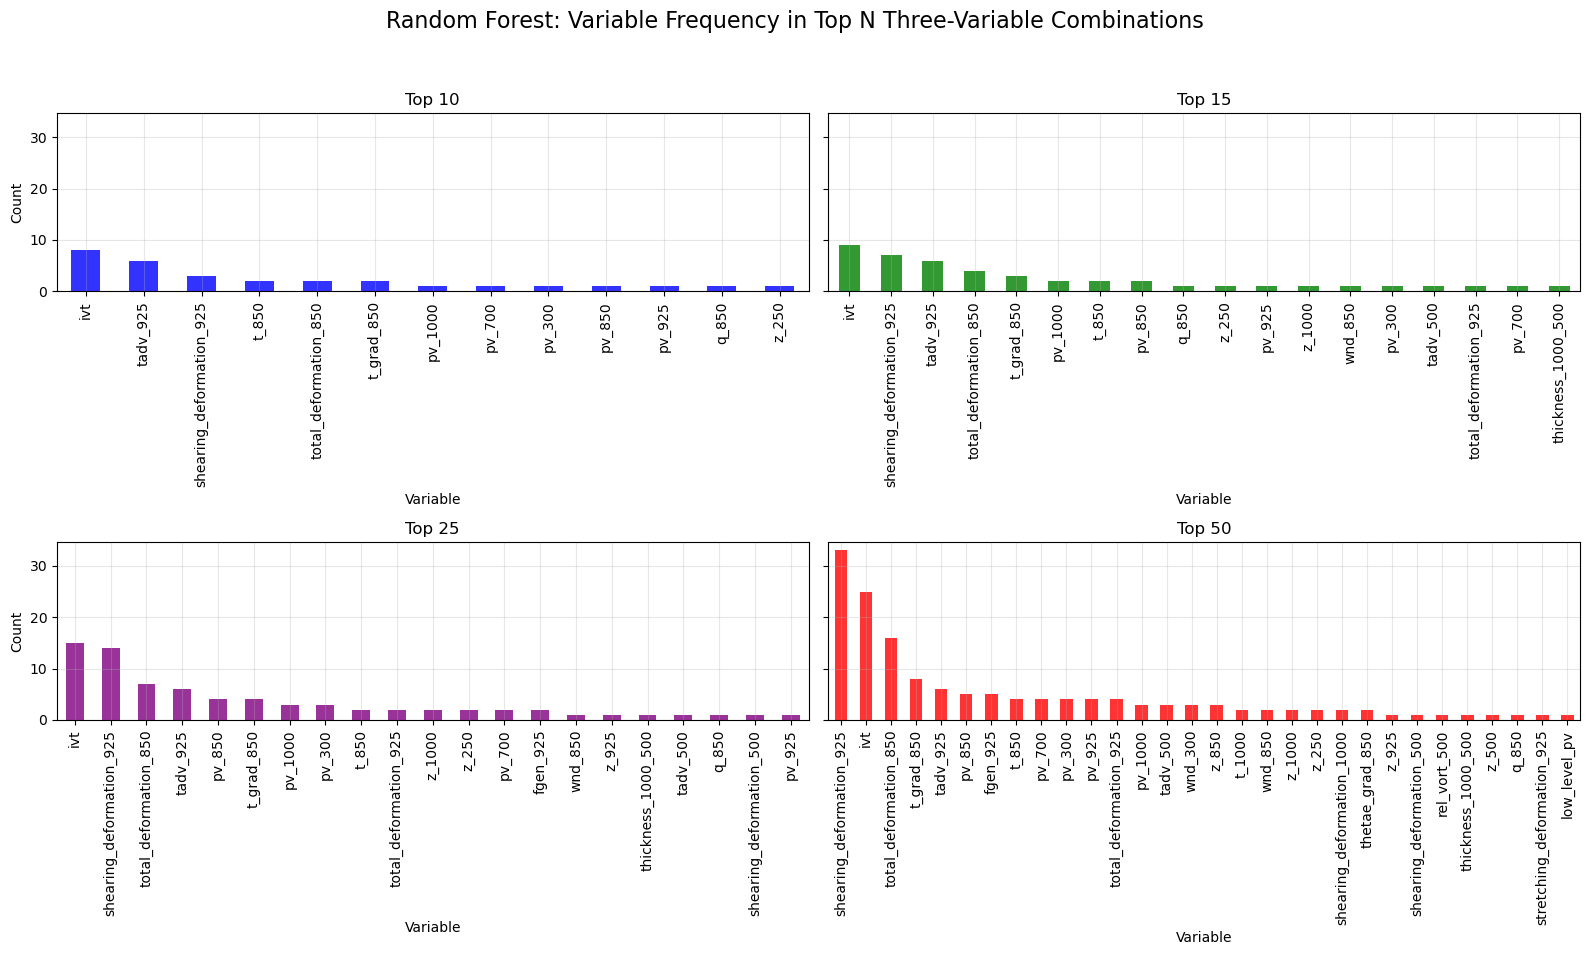

In [84]:
top_n_values = [10, 15, 25, 50]
color_map = {
    10: 'blue',
    15: 'green',
    25: 'purple',
    50: 'red'}

variable_counts = {}
for top_n in top_n_values:
    top_n_df = best_vars_df.head(top_n)
    counts = pd.concat([top_n_df['Var1'], top_n_df['Var2'], top_n_df['Var3']]).value_counts()
    variable_counts[top_n] = counts

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=True)

counts_10 = variable_counts[10]
counts_10.plot(kind='bar', ax=ax1, color=color_map[10], alpha=0.8, zorder=1)
ax1.set_title("Top 10", fontsize=12)
ax1.set_xlabel("Variable")
ax1.set_ylabel("Count")
ax1.grid(alpha=0.3, zorder=0)
ax1.tick_params(axis='x', rotation=90)

counts_15 = variable_counts[15]
counts_15.plot(kind='bar', ax=ax2, color=color_map[15], alpha=0.8, zorder=1)
ax2.set_title("Top 15", fontsize=12)
ax2.set_xlabel("Variable")
ax2.grid(alpha=0.3, zorder=0)
ax2.tick_params(axis='x', rotation=90)

counts_25 = variable_counts[25]
counts_25.plot(kind='bar', ax=ax3, color=color_map[25], alpha=0.8, zorder=1)
ax3.set_title("Top 25", fontsize=12)
ax3.set_xlabel("Variable")
ax3.set_ylabel("Count")
ax3.grid(alpha=0.3, zorder=0)
ax3.tick_params(axis='x', rotation=90)


counts_50 = variable_counts[50]
counts_50.plot(kind='bar', ax=ax4, color=color_map[50], alpha=0.8, zorder=1)
ax4.set_title("Top 50", fontsize=12)
ax4.set_xlabel("Variable")
ax4.grid(alpha=0.3, zorder=0)
ax4.tick_params(axis='x', rotation=90)

plt.suptitle("Random Forest: Variable Frequency in Top N Three-Variable Combinations", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Figure analysis:

Top 10: 
- IVT
- 925-hPa temperature advection
- 925-hPa shearing deformation 

Top 15: 
- IVT
- 925-hPa shearing deformation 
- 925-hPa temperature advection

Top 25: 
- IVT
- 925-hPa shearing deformation 
- 925-hPa total deformation 

Top 50: 
- 925-hPa shearing deformation
- IVT
- 850-hPa total deformation 

Let's try the first 10 variable combinations or so

In [86]:
var_1 = "ivt"
var_2 = "tadv_925"
var_3 = "shearing_deformation_925"

In [87]:
train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       0.75      1.00      0.86         3
       noMFW       1.00      0.86      0.92         7

    accuracy                           0.90        10
   macro avg       0.88      0.93      0.89        10
weighted avg       0.93      0.90      0.90        10




Wow - that combination is very good at separating events

Let's try a few others

In [89]:
var_1 = "ivt"
var_2 = "tadv_925"
var_3 = "total_deformation_850"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       0.60      1.00      0.75         3
       noMFW       1.00      0.71      0.83         7

    accuracy                           0.80        10
   macro avg       0.80      0.86      0.79        10
weighted avg       0.88      0.80      0.81        10




Not as good as the previous combination but still good!

Let's do one more

In [90]:
var_1 = "t_850"
var_2 = "tadv_850"
var_3 = "t_grad_850"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       0.25      0.33      0.29         3
       noMFW       0.67      0.57      0.62         7

    accuracy                           0.50        10
   macro avg       0.46      0.45      0.45        10
weighted avg       0.54      0.50      0.52        10




A little rough to say the least

Okay, now let's use the variable combinations with the highest estimated accuracy statistics 

First variable combination

In [91]:
var_1 = "t_850"
var_2 = "ivt"
var_3 = "t_grad_850"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      1.00      1.00         3
       noMFW       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10




Second variable combination

In [45]:
var_1 = "pv_1000"
var_2 = "ivt"
var_3 = "tadv_925"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      1.00      1.00         3
       noMFW       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10




Third variable combination

In [46]:
var_1 = "pv_700"
var_2 = "ivt"
var_3 = "tadv_925"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      1.00      1.00         3
       noMFW       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10




Fourth variable combination

In [47]:
var_1 = "pv_300"
var_2 = "ivt"
var_3 = "tadv_925"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      1.00      1.00         3
       noMFW       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10




Fifth variable combination

In [48]:
var_1 = "pv_850"
var_2 = "ivt"
var_3 = "tadv_925"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      1.00      1.00         3
       noMFW       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10




Sixth variable combination

In [49]:
var_1 = "pv_925"
var_2 = "ivt"
var_3 = "tadv_925"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      1.00      1.00         3
       noMFW       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10




Seventh variable combination

In [50]:
var_1 = "q_850"
var_2 = "ivt"
var_3 = "t_grad_850"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       1.00      1.00      1.00         3
       noMFW       1.00      1.00      1.00         7

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10




Eighth variable combination

In [51]:
var_1 = "shearing_deformation_925"
var_2 = "ivt"
var_3 = "t_grad_850"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       0.60      1.00      0.75         3
       noMFW       1.00      0.71      0.83         7

    accuracy                           0.80        10
   macro avg       0.80      0.86      0.79        10
weighted avg       0.88      0.80      0.81        10




Ninth variable combination

In [54]:
var_1 = "t_850"
var_2 = "total_deformation_850"
var_3 = "shearing_deformation_925"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       0.75      1.00      0.86         3
       noMFW       1.00      0.86      0.92         7

    accuracy                           0.90        10
   macro avg       0.88      0.93      0.89        10
weighted avg       0.93      0.90      0.90        10




Tenth variable combination

In [53]:
var_1 = "z_250"
var_2 = "total_deformation_850"
var_3 = "shearing_deformation_925"

train_and_evaluate_rf(
    train_df=train_df,
    test_df=test_df,
    var1=var_1,
    var2=var_2,
    var3=var_3,
    label_col="label",
    random_state=zid,
    n_estimators=n_estimators,
    max_depth=max_depth,
    min_samples_split=min_samples_split,
    min_samples_leaf=min_samples_leaf)

Classification report for classifier RandomForestClassifier(random_state=1895595):
              precision    recall  f1-score   support

         MFW       0.75      1.00      0.86         3
       noMFW       1.00      0.86      0.92         7

    accuracy                           0.90        10
   macro avg       0.88      0.93      0.89        10
weighted avg       0.93      0.90      0.90        10


